In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

In [3]:
train.isnull().sum()

Unnamed: 0           0
RowId                0
Date                 0
SecuritiesCode       0
Open              6503
High              6503
Low               6503
Close             6503
Volume               0
Target             238
dtype: int64

In [4]:
train.shape, test.shape

((1866532, 10), (465999, 10))

In [6]:
train.head()

,Unnamed: 0,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,Target
0,0,20170104_1301,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,0.000730
1,1,20170104_7412,2017-01-04,7412,719.0,725.0,719.0,721.0,201400,0.000000
2,2,20170104_7408,2017-01-04,7408,2459.0,2518.0,2447.0,2500.0,110900,0.004421
3,3,20170104_7315,2017-01-04,7315,465.0,494.0,465.0,493.0,41100,-0.004032
4,4,20170104_7313,2017-01-04,7313,3055.0,3150.0,3045.0,3135.0,248600,-0.009693


In [8]:
test.head(5)

,Unnamed: 0,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,Target
0,1866532,20201222_7244,2020-12-22,7244,677.0,682.0,661.0,668.0,345000,0.043544
1,1866533,20201222_7245,2020-12-22,7245,504.0,505.0,492.0,494.0,190700,0.010101
2,1866534,20201222_7246,2020-12-22,7246,311.0,311.0,304.0,306.0,273000,0.023490
3,1866535,20201222_7250,2020-12-22,7250,1100.0,1115.0,1080.0,1100.0,121700,0.008443
4,1866536,20201222_7272,2020-12-22,7272,2090.0,2111.0,2077.0,2100.0,1265800,0.011544


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1866532 entries, 0 to 1866531
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Unnamed: 0      int64  
 1   RowId           object 
 2   Date            object 
 3   SecuritiesCode  int64  
 4   Open            float64
 5   High            float64
 6   Low             float64
 7   Close           float64
 8   Volume          int64  
 9   Target          float64
dtypes: float64(5), int64(3), object(2)
memory usage: 142.4+ MB


Ukuran data asli : (1866532, 10)
Ukuran sampel     : (100000, 10)


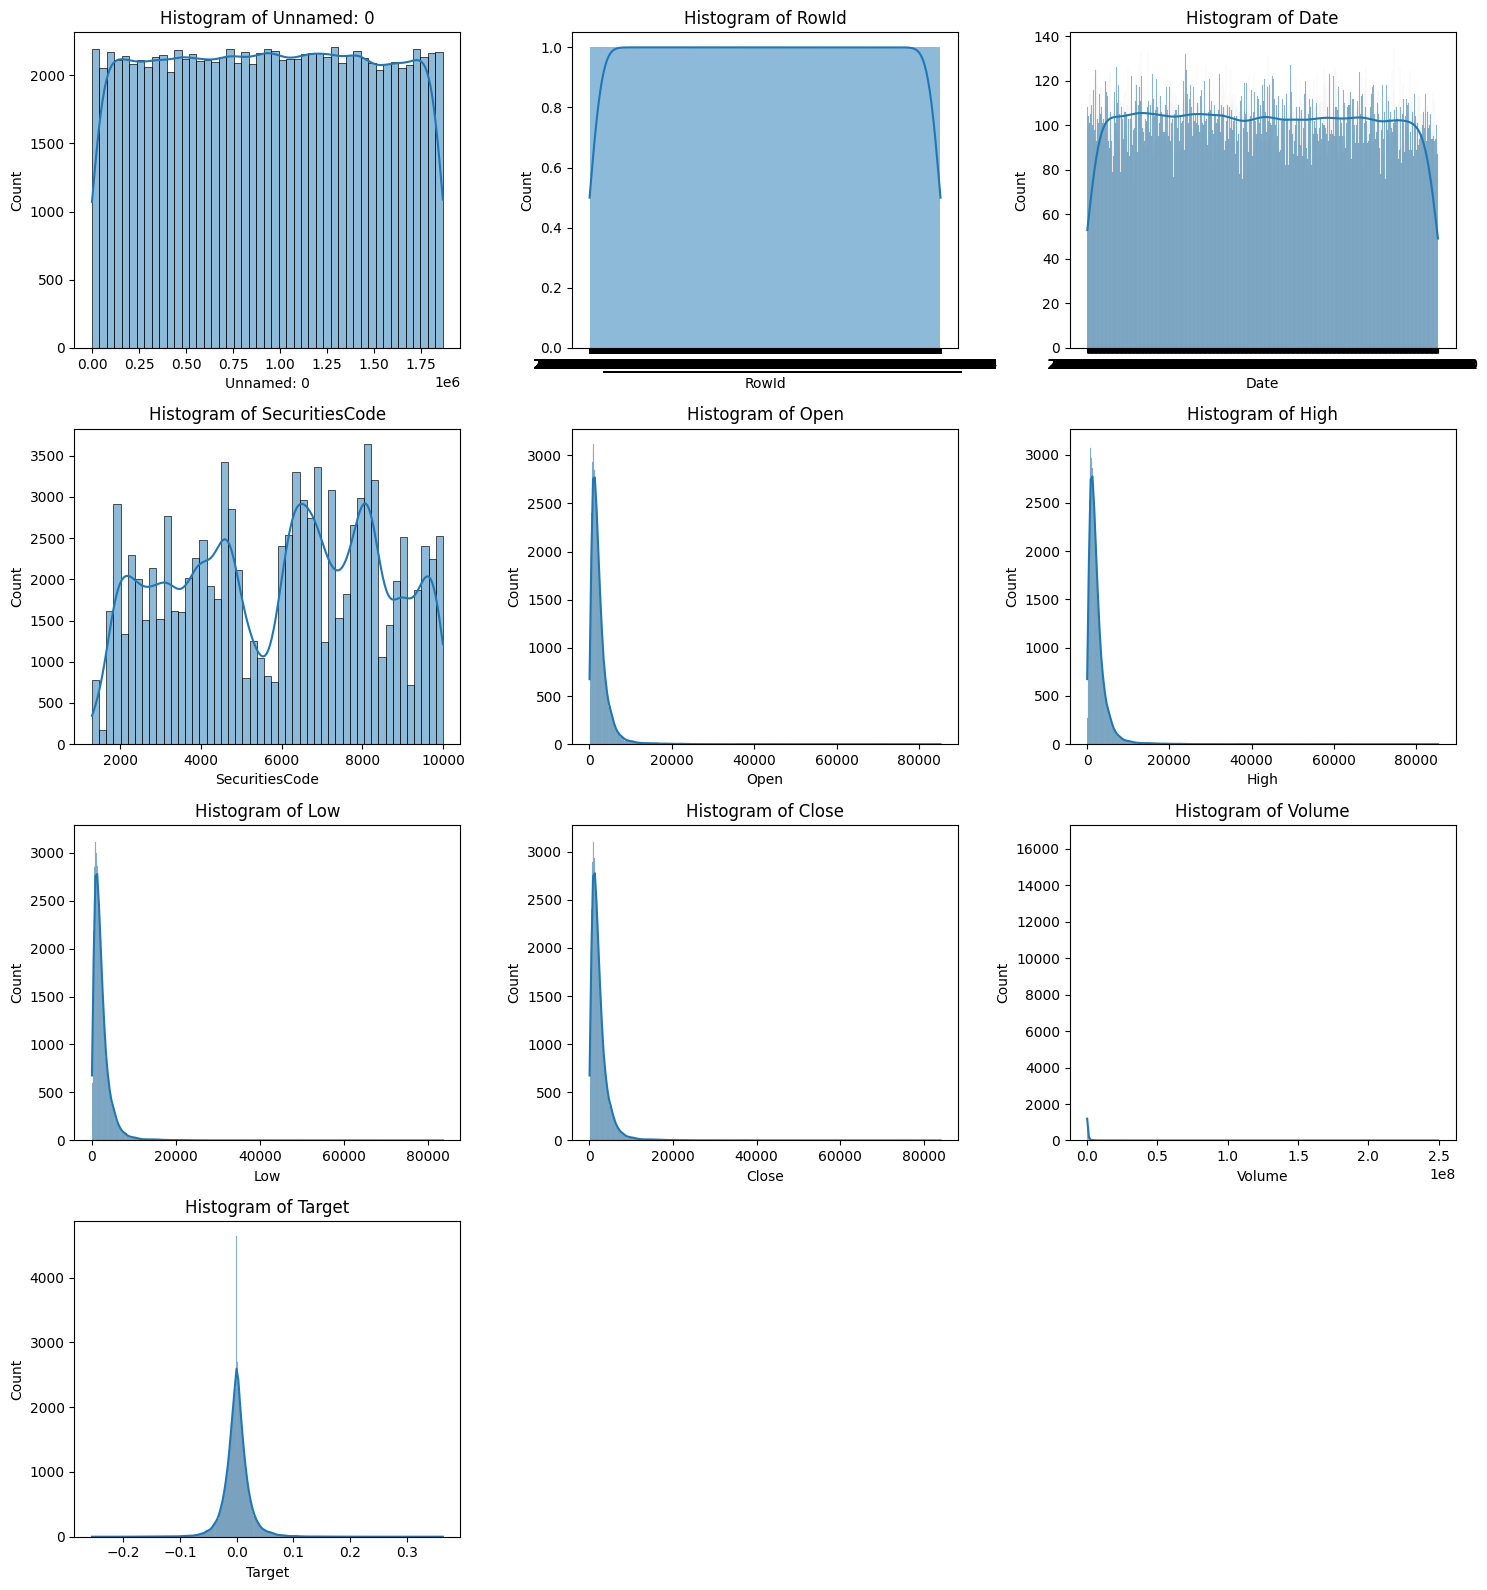

In [10]:
import math

SAMPLE_SIZE = 100000   # sesuaikan, cukup untuk merepresentasikan distribusi tanpa berat

train_sample = train.sample(n=min(SAMPLE_SIZE, len(train)), random_state=42)

print(f"Ukuran data asli : {train.shape}")
print(f"Ukuran sampel     : {train_sample.shape}")

cols = train_sample.columns.tolist()
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(train_sample[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Ukuran data asli : (1866532, 10)
Ukuran sampel     : (100000, 10)


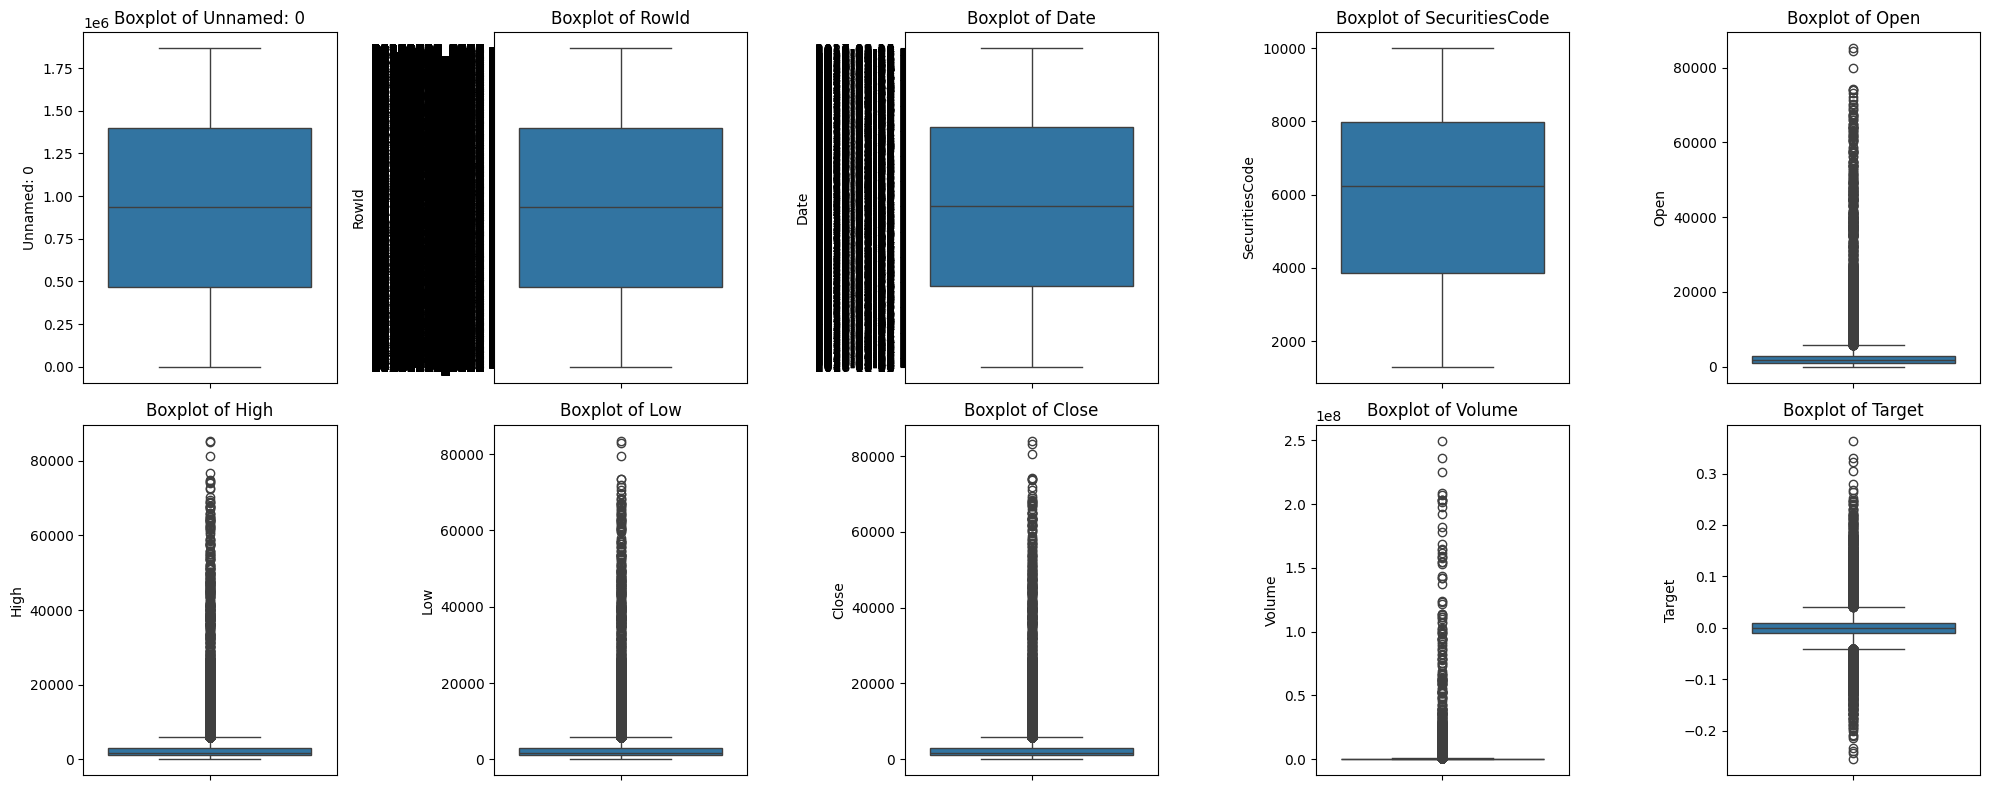

In [12]:
# Sampling 100.000 data sebelum membuat boxplot
SAMPLE_SIZE = 100_000

train_sample = train.sample(n=min(SAMPLE_SIZE, len(train)), random_state=42)

print(f"Ukuran data asli : {train.shape}")
print(f"Ukuran sampel     : {train_sample.shape}")

# plot boxplot of each column (1 row = 5 kolom), pakai data hasil sampling
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = train_sample.columns.tolist()
n_cols = 5
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=train_sample[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#EDA the seasonality of the data
